# IS445: Assignment 2
### Nataly Panczyk
Importing and preparing the data

In [100]:
%matplotlib inline

In [101]:
import wget

In [102]:
url = 'https://uiuc-ischool-dataviz.github.io/spring2019online/week02/building_inventory.csv'
building_file = wget.download(url)

100% [..........................................................................] 1994275 / 1994275

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets
import pandas as pd

In [104]:
df = pd.read_csv(building_file, na_values={
    'Year Acquired': 0,
    'Year Constructed': 0,
    'Square Footage': 0,
    'Congress Dist':0,
    'Total Floors':0
})

In [105]:
df.columns

Index(['Agency Name', 'Location Name', 'Address', 'City', 'Zip code', 'County',
       'Congress Dist', 'Congressional Full Name', 'Rep Dist', 'Rep Full Name',
       'Senate Dist', 'Senator Full Name', 'Bldg Status', 'Year Acquired',
       'Year Constructed', 'Square Footage', 'Total Floors',
       'Floors Above Grade', 'Floors Below Grade', 'Usage Description',
       'Usage Description 2', 'Usage Description 3'],
      dtype='object')

## Relationship between the year acquired and the year constructed.
To demonstrate this relationship, I created a scatterplot where x is the year the building was acquired and y is the year the building was constructed. I think this plot is fairly successful in showing the relationship between these two factors-- they're certainly related. It looks like most of the buildings in this inventory were acquired the same year they were constructed, hence the y=x trendline seen on this plot. Shortcomings of this approach include the markers and the simplicity. I chose to use a '.' marker for this scatterplot because there were so many overlapping data points, but it's still a little difficult to discern them all. Furthermore, I think this plot is a little boring, but otherwise effective. 

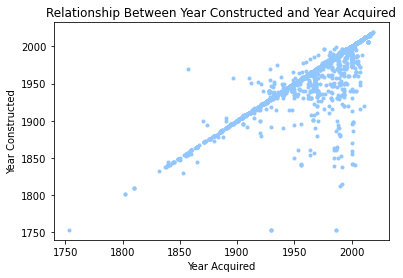

In [216]:
# Relationship between the year acquired and the year constructed
with plt.style.context('seaborn-pastel'):
    fig, ax = plt.subplots()
    year_acquired = df['Year Acquired']
    year_constructed = df['Year Constructed']
    ax.scatter(year_acquired, year_constructed, marker='.')
    ax.set_title('Relationship Between Year Constructed and Year Acquired')
    ax.set_xlabel('Year Acquired')
    ax.set_ylabel('Year Constructed')

## Average square footage per floor and total square footage as a function of congressional district

### Average square footage per floor
To make this plot, I started by making an array of all the unique congressional districts in the database. Then, I made arrays of the total square footage and the total number of floors for each district by iterating through each row of the database and checking the district to figure out where to put the data. I then divided teh total square footage by the total number of floors to find the average square footage per floor based on congressional district. I made this plot using matplotlib's bar() function, but this probably could've been done another way using a histogram. I think this plot is relatively successful in showing the trends (i.e. which congressional districts have the most/least square footage per floor). However, two major shortcomings with this plot were 1: that the congressional districts are shown as floats instead of strings. It was really difficult trying to get these to show up nicely because of the nan values. Also, the fact that the districts don't go in ascending order might be bothersome to some people. And 2: the database clearly had missing information for some buildings, and this plot doesn't remove that data. So, in a way it seems like this says that the average square footage per floor in the 14th congressional district is 0, but in reality, there are just data missing.
## Total square footage as a function of congressional district
I made this plot the exact same way that I made the average square footage per floor by congressional district plot, I just simply didn't divide the square footage by the number of floors. I also tried plotting this on the same figure as the average square footage per floor plot, but because of the magnitude difference, the data weren't visible. As with the previous plot, I also think this visualization is a little problematic in the lacking values for various congressional districts and the x-axis labels. Still, I like that this plot is very quick to read and doesn't require an extensive amount of explanation. Another problem with the magnitude of this plot is that there is so much square footage in the 7th district, that it makes it difficult to see the specifics of the smaller values (like the 6th or 9th districts). 

In [140]:
# creating the arrays of data for average square footage per floor by district
minidf = df[['Congress Dist', 'Square Footage', 'Total Floors']]
districts = minidf['Congress Dist'].unique()
avg_sqpf = np.zeros(len(districts))
tfootage = np.zeros(len(districts))
for i in range(len(districts)):
    dist = districts[i]
    total_footage = 0
    total_floors = 0
    for j in range( len(minidf['Congress Dist'])):
        if minidf['Congress Dist'][j] == dist:
            total_footage += minidf['Square Footage'][j]
            total_floors += minidf['Total Floors'][j]
        else:
            continue
    if total_floors == 0:
        avg_sqpf[i] = 0
    else:
        avg_sqpf[i] = total_footage/total_floors
        tfootage[i] = total_footage
district_labels = districts
'''print( type(districts[0] ) )
for i in range(len(districts)):
    if districts[i] is np.float64:
        district_labels.append(int(districts[i]))
    else:
        district_labels.append(str(districts[i]))'''


'print( type(districts[0] ) )\nfor i in range(len(districts)):\n    if districts[i] is np.float64:\n        district_labels.append(int(districts[i]))\n    else:\n        district_labels.append(str(districts[i]))'

In [141]:
avg_sqpf

array([           nan,            nan,            nan,            nan,
                  nan,            nan, 17967.875     ,            nan,
        5202.10714286,     0.        ,            nan,            nan,
        4684.44871795,  7088.90909091,            nan,            nan,
        4362.75586854, 16009.04424779, 15130.52380952])

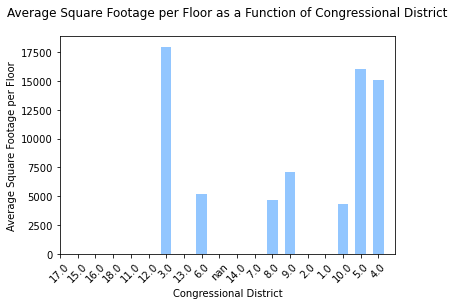

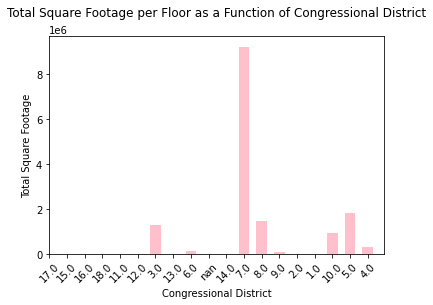

In [226]:
# make plot
with plt.style.context('seaborn-pastel'):
    fig, ax = plt.subplots()
    w = 0.6
    x = np.arange(len(district_labels))
    ax.bar(x, avg_sqpf, width=0.6, label='average sq footage per floor')
    ax.set_xlabel('Congressional District')
    ax.set_xticks(x)
    ax.set_xticklabels(district_labels, rotation=45)
    ax.set_ylabel('Average Square Footage per Floor')
    ax.set_title('Average Square Footage per Floor as a Function of Congressional District', pad=20)
    #print( district_labels )
    
    fig, ax = plt.subplots() 
    ax.bar(x, tfootage, width=0.6, label='total square footage', color='pink')
    ax.set_xlabel('Congressional District')
    ax.set_xticks(x)
    ax.set_xticklabels(district_labels, rotation=45)
    ax.set_ylabel('Total Square Footage')
    ax.set_title('Total Square Footage per Floor as a Function of Congressional District', pad=20)
    
    

# Square footage for the five most common departments as a function of year.
I made this plot by first figuring out what the top 5 departments were for the dataset. Then, I found the square footage and year acquired of each building within those departments and plotted them on an overlapping scatterplot. I tried a version of these where I plotted each department on a separate figure, but I thought that is was more valuable to have the data all in one place so a viewer could compare across departments. That said, I think this plot is really successful in showing the differences in patterns between departments at the expense of showing detailed patterns for each department. I also played around with the opacities to try to make all the points as visible as possible, but that led to the slightly misleading situation with the purple points (Detention & Correctional Facilities). Because there are so many overlapping points in this set, they start to block the other data even though they are the lightest shade. I also thought this plot was really convenient for showing stark outliers, so it probably would've worked better as an approach for a plot that had more spread out data. 


['Storage', 'Unusual', 'Industrial', 'Assembly', 'Detention & Correc']


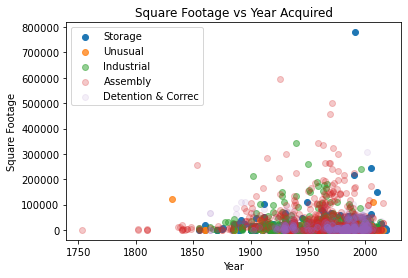

In [213]:
depts = df['Usage Description'].unique()
df2 = df[['Square Footage', 'Usage Description', 'Year Acquired', 'Year Constructed']]
dept_freq = np.zeros(len(depts))
for h in range(len(depts)):
    for i in range(len(df2['Usage Description'])):
        if df2['Usage Description'][i] == depts[h]:
            dept_freq[h] += 1
top_depts_q = np.flip( np.sort(dept_freq) )
top_depts_index = np.array([1, 0, 3, 2, 9])
top_depts = []
for i in range(len(top_depts_index)):
    top_depts.append( depts[top_depts_index[i]] )
print( top_depts )
sf_storage = []
sf_unusual = []
sf_industrial = []
sf_assembly = []
sf_dc = []
sf_array = [sf_storage, sf_unusual, sf_industrial, sf_assembly, sf_dc]
year_storage = []
year_unusual = []
year_industrial = []
year_assembly = []
year_dc = []
year_array = [year_storage, year_unusual, year_industrial, year_assembly, year_dc]
for i in range(len(top_depts)):
    for j in range(len(df2['Square Footage'])):
        if df2['Usage Description'][j] == top_depts[i]:
            sf_array[i].append(df2['Square Footage'][j])
            year_array[i].append(df2['Year Acquired'][j])

fig, ax = plt.subplots()
alphas = np.array([1, 0.75, 0.5, 0.25, 0.1])
with plt.style.context('seaborn-pastel'):
    for i in range(len(sf_array)):
        #fig, ax = plt.subplots()
        ax.scatter(year_array[i], sf_array[i], marker='o', alpha = alphas[i], label=top_depts[i])
        ax.set_title( 'Square Footage vs Year Acquired' )
        ax.legend()
        ax.set_xlabel('Year')
        ax.set_ylabel('Square Footage')

In [227]:
fM1 = 0.005
fM2 = 0.002
fM3 = 0.002
fM4 = 4e-5
t1 = fM1 + fM2 + fM3 + fM4 
t2 = fM1*fM2 + fM1*fM3 + fM1*fM4 + fM2*fM3 + fM2*fM4 + fM3*fM4
t3 = fM1*fM2*fM3 + fM2*fM3*fM4 + fM1*fM3*fM4 
t4 = fM1*fM2*fM3*fM4
freq = t1 - t2 + t3 - t4
print( freq )

0.0090156605592


In [228]:
f1 = 0.000722
f2 = 0
f3 = freq
ffail = f1 + f2 + f3 - f1*f2 - f1*f3 - f2*f3 + f1*f2*f3
print( ffail )

0.00973115125227626
